# **영상의 밝기(Brightness) 조절**

Mounted at /content/gdrive


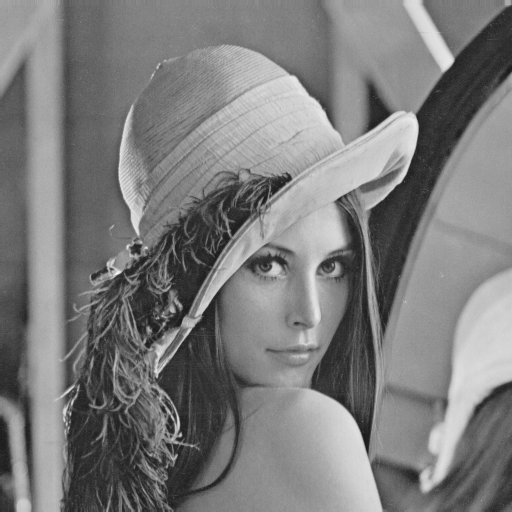

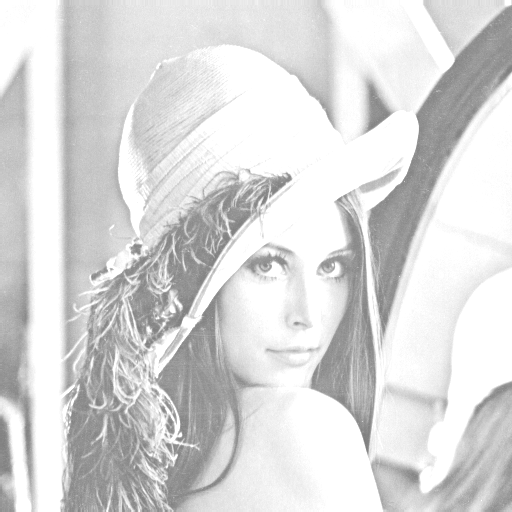

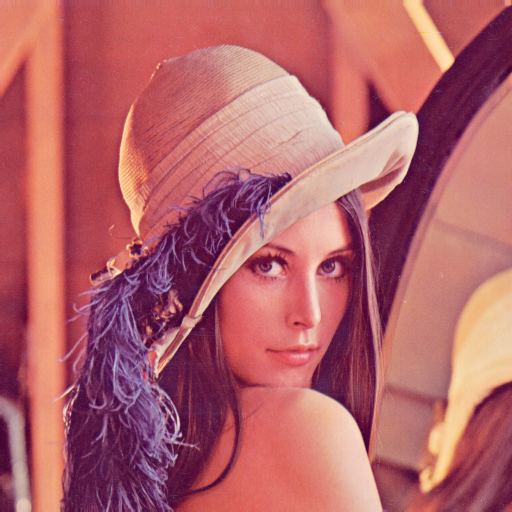

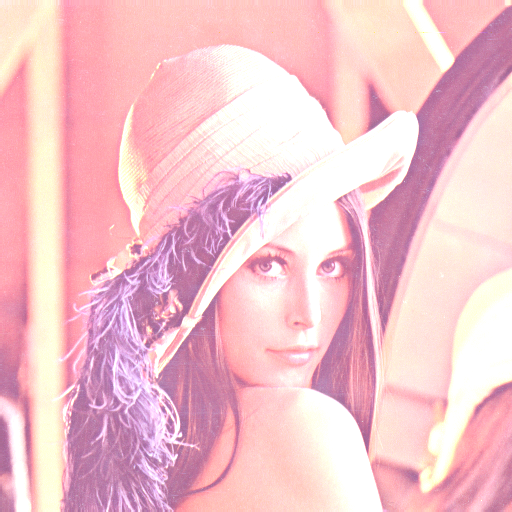

In [ ]:
# 구글 드라이브에 연결하기
from google.colab import drive
drive.mount('/content/gdrive')

# 구글 코랩에서 OpenCV의 cv2.imshow()대신 cv2_imshow() 사용
from google.colab.patches import cv2_imshow

import sys
import numpy as np
import cv2

# 그레이스케일 영상 불러오기
src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/lenna.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

dst = cv2.add(src, 100)
#dst = np.clip(src + 100., 0, 255).astype(np.uint8)

cv2_imshow(src)
cv2_imshow(dst)
# cv2.waitKey()

# 컬러 영상 불러오기
src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/lenna.bmp')

if src is None:
    print('Image load failed!')
    sys.exit()

dst = cv2.add(src, (100, 100, 100, 0))
#dst = np.clip(src + 100., 0, 255).astype(np.uint8)

cv2_imshow(src)
cv2_imshow(dst)
# cv2.waitKey()

# cv2.destroyAllWindows()

# 2. 영상의 산술(Arithmetic) 연산 : /content/gdrive/My Drive/Colab Notebooks/data 폴더에 그림 위치함

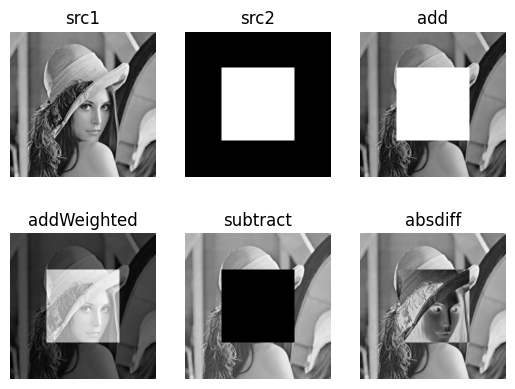

In [ ]:
import sys
import numpy as np
import cv2
from matplotlib import pyplot as plt


src1 = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/lenna256.bmp', cv2.IMREAD_GRAYSCALE)
src2 = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/square.bmp', cv2.IMREAD_GRAYSCALE)

if src1 is None or src2 is None:
    print('Image load failed!')
    sys.exit()

dst1 = cv2.add(src1, src2, dtype=cv2.CV_8U)
dst2 = cv2.addWeighted(src1, 0.5, src2, 0.5, 0.0)
dst3 = cv2.subtract(src1, src2)
dst4 = cv2.absdiff(src1, src2)

plt.subplot(231), plt.axis('off'), plt.imshow(src1, 'gray'), plt.title('src1')
plt.subplot(232), plt.axis('off'), plt.imshow(src2, 'gray'), plt.title('src2')
plt.subplot(233), plt.axis('off'), plt.imshow(dst1, 'gray'), plt.title('add')
plt.subplot(234), plt.axis('off'), plt.imshow(dst2, 'gray'), plt.title('addWeighted')
plt.subplot(235), plt.axis('off'), plt.imshow(dst3, 'gray'), plt.title('subtract')
plt.subplot(236), plt.axis('off'), plt.imshow(dst4, 'gray'), plt.title('absdiff')
plt.show()

# 3. 컬러 영상과 색공간

src.shape: (480, 640, 3)
src.dtype: uint8


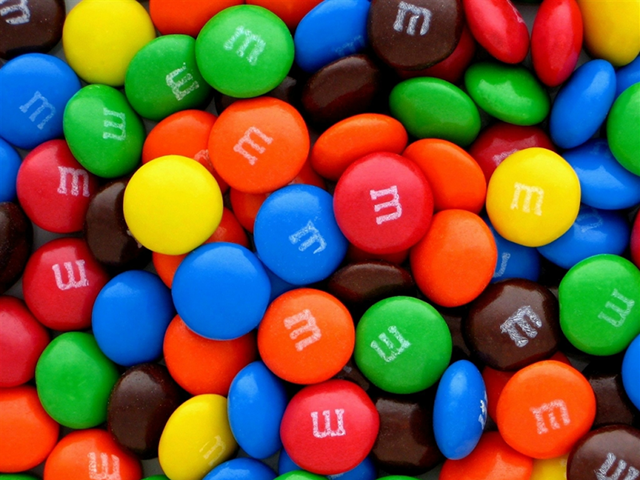

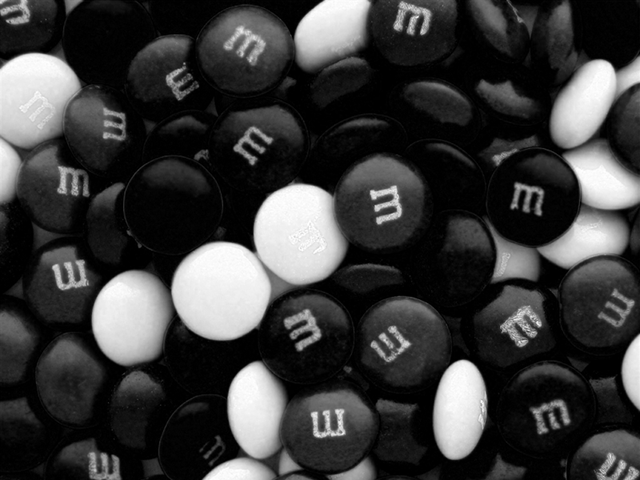

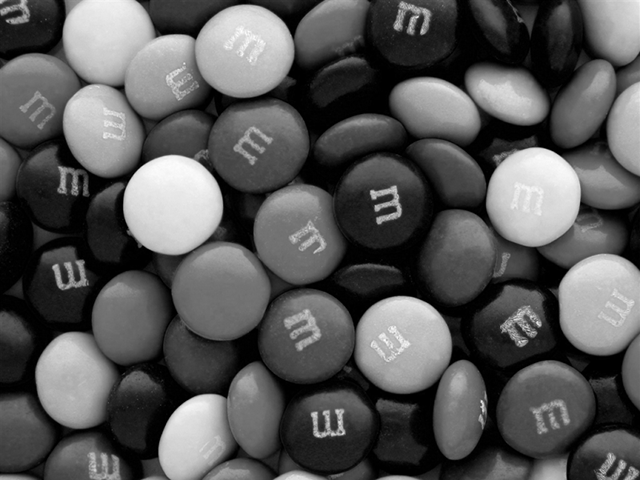

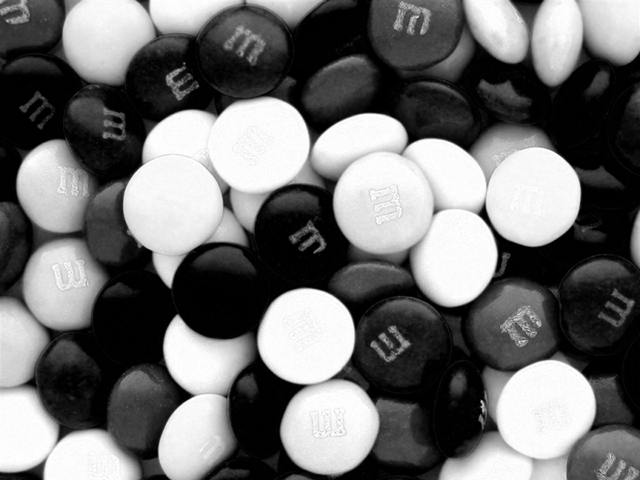

In [ ]:
import sys
import numpy as np
import cv2


# 컬러 영상 불러오기
src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/candies.png', cv2.IMREAD_COLOR)

if src is None:
    print('Image load failed!')
    sys.exit()

# 컬러 영상 속성 확인
print('src.shape:', src.shape)  # src.shape: (480, 640, 3)
print('src.dtype:', src.dtype)  # src.dtype: uint8

# RGB 색 평면 분할
b_plane, g_plane, r_plane = cv2.split(src)

#b_plane = src[:, :, 0]
#g_plane = src[:, :, 1]
#r_plane = src[:, :, 2]

cv2_imshow(src)
cv2_imshow(b_plane)
cv2_imshow(g_plane)
cv2_imshow(r_plane)
# cv2.waitKey()

# cv2.destroyAllWindows()

# 4. 영상의 색공간 분리

src.shape: (480, 640, 3)
src.dtype: uint8


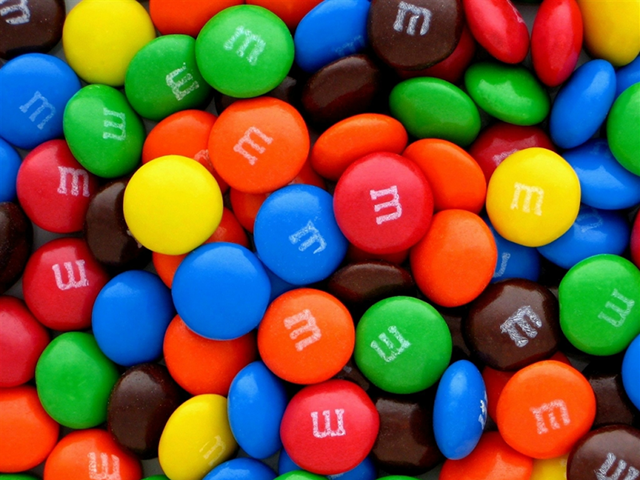

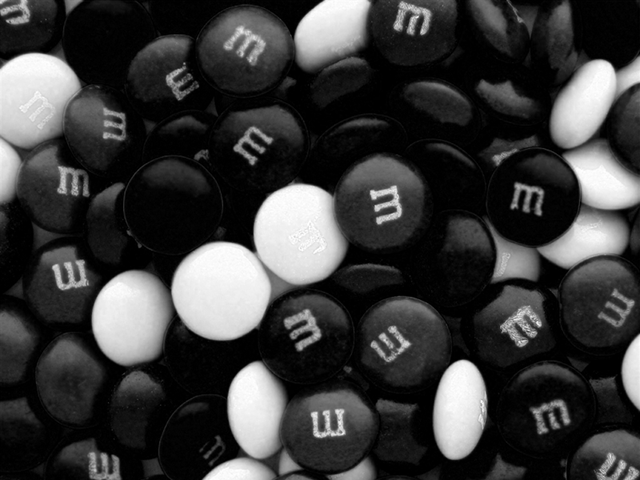

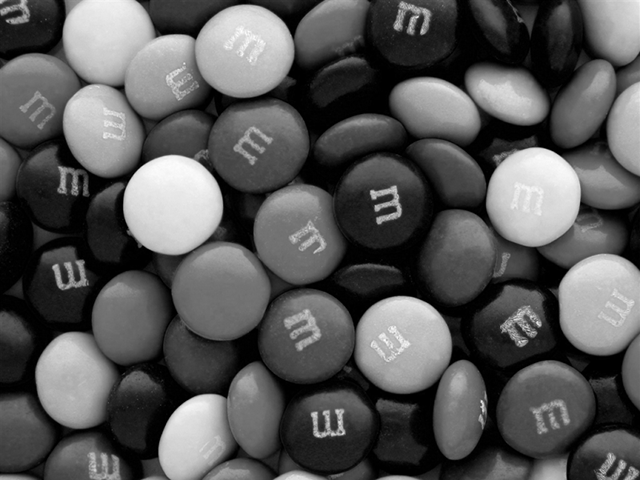

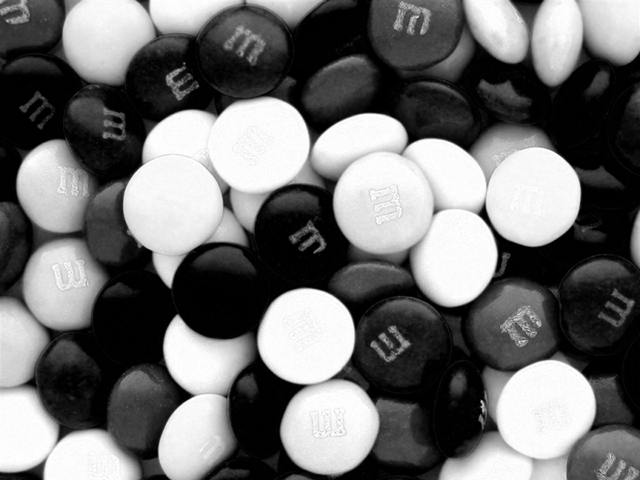

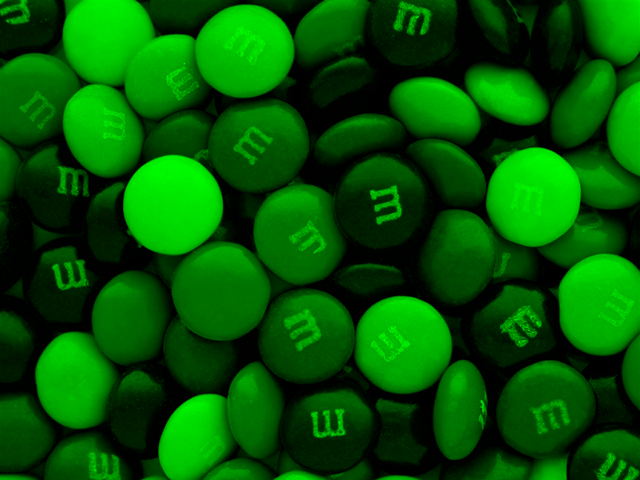

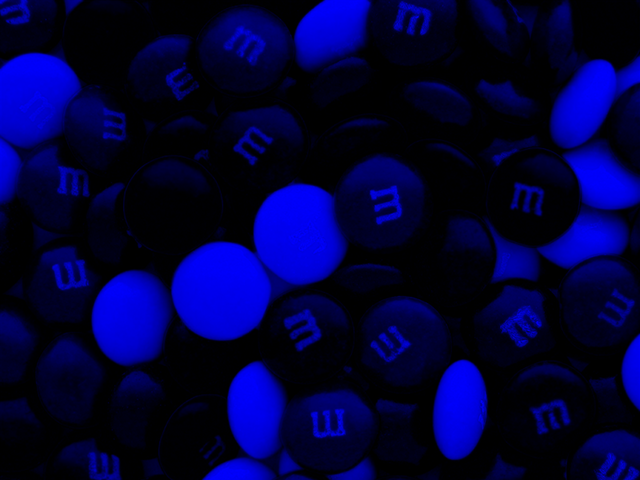

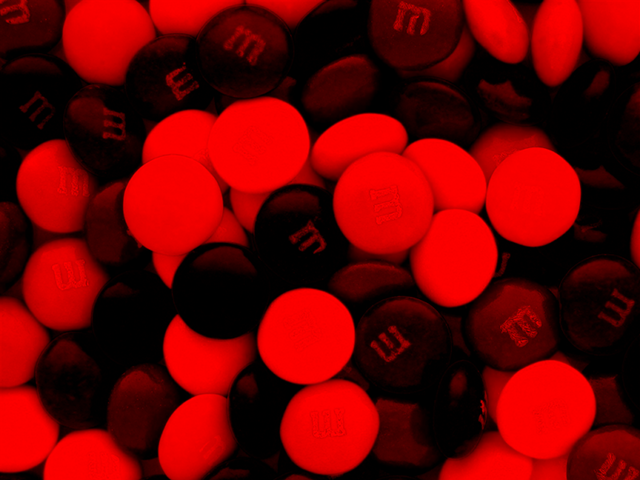

In [ ]:
import sys
import numpy as np
import cv2


# 컬러 영상 불러오기
src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/candies.png', cv2.IMREAD_COLOR)

if src is None:
    print('Image load failed!')
    sys.exit()

# 컬러 영상 속성 확인
print('src.shape:', src.shape)  # src.shape: (480, 640, 3)
print('src.dtype:', src.dtype)  # src.dtype: uint8

# RGB 색 평면 분할
b_plane, g_plane, r_plane = cv2.split(src)

#b_plane = src[:, :, 0]
#g_plane = src[:, :, 1]
#r_plane = src[:, :, 2]

# green plane only
img2 = np.zeros((480,640,3), np.uint8)
img2[:, :, 0] = 0
img2[:, :, 1] = g_plane
img2[:, :, 2] = 0

# blue plane only
img3 = np.zeros((480,640,3), np.uint8)
img3[:, :, 0] = b_plane
img3[:, :, 1] = 0
img3[:, :, 2] = 0

# red plane only
img4 = np.zeros((480,640,3), np.uint8)
img4[:, :, 0] = 0
img4[:, :, 1] = 0
img4[:, :, 2] = r_plane

cv2_imshow(src)
cv2_imshow(b_plane)
cv2_imshow(g_plane)
cv2_imshow(r_plane)

cv2_imshow(img2) # green plane
cv2_imshow(img3) # blue plane
cv2_imshow(img4) # red plane

# cv2.waitKey()

# cv2.destroyAllWindows()

# 5. 영상의 히스토그램 구하기

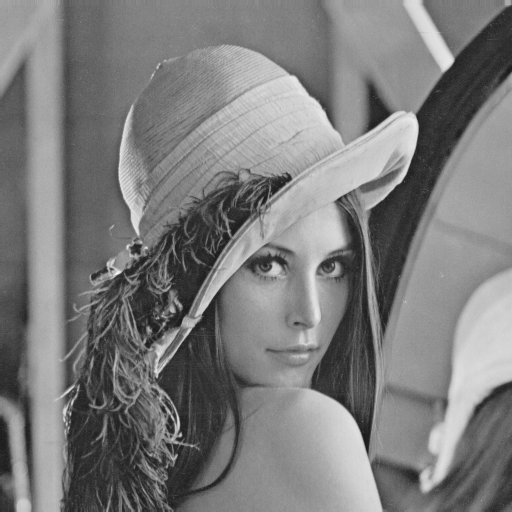

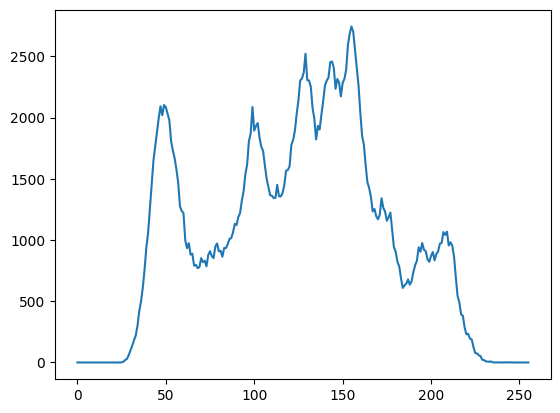

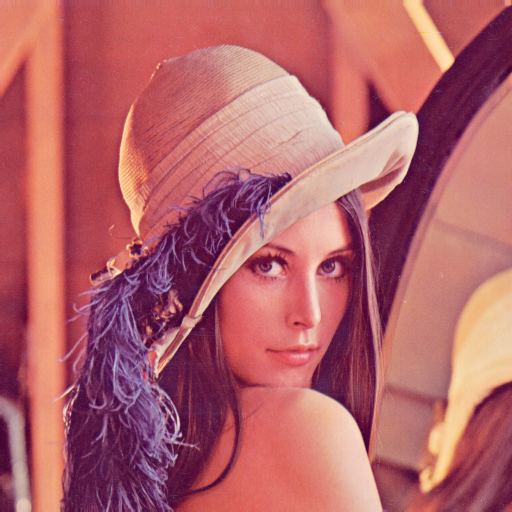

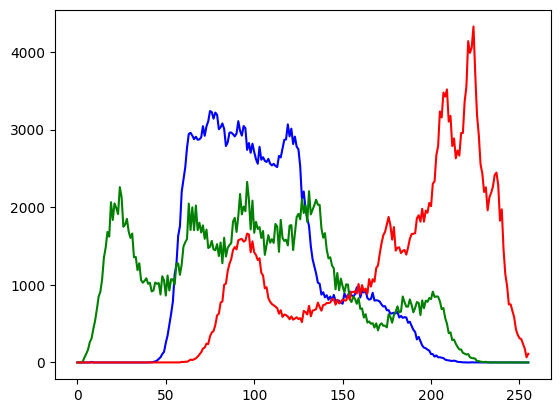

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cv2


# 그레이스케일 영상의 히스토그램
src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/lenna.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

hist = cv2.calcHist([src], [0], None, [256], [0, 256])

cv2_imshow(src)
# cv2.waitKey(1)

plt.plot(hist)
plt.show()

# 컬러 영상의 히스토그램
src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/lenna.bmp')

if src is None:
    print('Image load failed!')
    sys.exit()

colors = ['b', 'g', 'r']
bgr_planes = cv2.split(src)

for (p, c) in zip(bgr_planes, colors):
    hist = cv2.calcHist([p], [0], None, [256], [0, 256])
    plt.plot(hist, color=c)

cv2_imshow(src)
# cv2.waitKey(1)

plt.show()

# cv2.destroyAllWindows()